<a href="https://colab.research.google.com/github/Ashu-42/quant_research_crypto_volatility_forecasting/blob/quant_DL_ashu/notebooks/12_Final_Robustness_Comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 12 — Final Robustness Comparison

This notebook combines the two completed validation experiments:

### Primary target
Next-day daily squared log return:

\[
r_{t+1}^2
\]

### Robustness target
Next-day updated 30-day rolling historical variance:

\[
HV^2_{30,t+1}
\]

The purpose is **not** to compare the absolute magnitude of MAE, RMSE or QLIKE across the two target definitions.  
The targets have different statistical properties and the rolling-30 target is mechanically much smoother.

Instead, the robustness analysis focuses on:

- within-target QLIKE rankings;
- whether the winning model family changes;
- whether ARCH remains stronger than Global DL;
- whether the relative ordering of common models is stable;
- whether Global DL improves over persistence within each target definition.

The untouched test set is not used.

## 1. Imports and project paths

In [1]:
from google.colab import drive
from pathlib import Path

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

drive.mount("/content/drive")

PROJECT_DIR = Path(
    "/content/drive/MyDrive/Quant Research"
)

RESULTS_DIR = (
    PROJECT_DIR
    / "results"
)

OUTPUT_DIR = (
    RESULTS_DIR
    / "FINAL_ROBUSTNESS_COMPARISON"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

PRIMARY_FINAL_CORE_PATH = (
    RESULTS_DIR
    / "FINAL_MODEL_COMPARISON"
    / "core_cross_asset_validation_comparison.csv"
)

PRIMARY_GLOBAL_PATH = (
    RESULTS_DIR
    / "GLOBAL_4_ASSETS"
    / "final_validation_comparison_by_asset.csv"
)

PRIMARY_ARCH_CANDIDATES = [
    RESULTS_DIR
    / "arch_family"
    / "arch_validation_metrics.csv",

    RESULTS_DIR
    / "ARCH_FAMILY"
    / "daily_returns"
    / "validation"
    / "arch_validation_metrics_by_asset.csv",
]

ROLLING30_CORE_PATH = (
    RESULTS_DIR
    / "rolling30_historical_variance"
    / "GLOBAL_4_ASSETS"
    / "rolling30_final_validation_comparison_by_asset.csv"
)

ROLLING30_BTC_ALL_PATH = (
    RESULTS_DIR
    / "rolling30_historical_variance"
    / "BTCUSDT"
    / "rolling30_btc_all_models_validation_comparison.csv"
)

print("Output directory:")
print(OUTPUT_DIR)

Mounted at /content/drive
Output directory:
/content/drive/MyDrive/Quant Research/results/FINAL_ROBUSTNESS_COMPARISON


## 2. Normalization helpers

In [2]:
ASSETS = [
    "BTCUSDT",
    "ETHUSDT",
    "SOLUSDT",
    "XRPUSDT",
]

ASSET_MAP = {
    "BTC": "BTCUSDT",
    "BTCUSDT": "BTCUSDT",
    "ETH": "ETHUSDT",
    "ETHUSDT": "ETHUSDT",
    "SOL": "SOLUSDT",
    "SOLUSDT": "SOLUSDT",
    "XRP": "XRPUSDT",
    "XRPUSDT": "XRPUSDT",
}

PRIMARY_TARGET = (
    "Daily Squared Return Variance"
)

ROLLING30_TARGET = (
    "Rolling-30 Historical Variance"
)

PRIMARY_BASELINE_MAP = {
    "Persistence":
        "Persistence",

    "7-Day Mean RV":
        "7-Day Mean",

    "30-Day Mean RV":
        "30-Day Mean",
}

ROLLING30_BASELINE_MAP = {
    "Rolling30 Persistence":
        "Persistence",

    "7-Day Mean Rolling30 Variance":
        "7-Day Mean",

    "30-Day Mean Rolling30 Variance":
        "30-Day Mean",
}


def normalize_asset(value):
    key = str(value).strip().upper()

    return ASSET_MAP.get(
        key,
        key,
    )


def normalize_columns(df):
    out = df.copy()

    out.columns = [
        str(column)
        .strip()
        .lower()
        for column
        in out.columns
    ]

    rename_map = {
        "symbol":
            "asset",

        "model_name":
            "model",

        "observations":
            "n_observations",

        "n_validation":
            "n_observations",

        "source_scope":
            "scope",
    }

    out = out.rename(
        columns={
            old: new
            for old, new
            in rename_map.items()
            if old in out.columns
        }
    )

    required = {
        "asset",
        "model",
        "mae",
        "rmse",
        "qlike",
    }

    missing = (
        required
        - set(
            out.columns
        )
    )

    if missing:
        raise ValueError(
            "Missing required metric columns: "
            f"{missing}"
        )

    if (
        "n_observations"
        not in out.columns
    ):
        out[
            "n_observations"
        ] = np.nan

    out["asset"] = (
        out["asset"]
        .map(
            normalize_asset
        )
    )

    for metric in [
        "mae",
        "rmse",
        "qlike",
        "n_observations",
    ]:
        out[metric] = pd.to_numeric(
            out[metric],
            errors="coerce",
        )

    return out


def model_family(
    model,
    scope=None,
):
    model_upper = (
        str(model)
        .upper()
    )

    scope_text = (
        ""
        if scope is None
        else str(scope)
    )

    if (
        "GARCH"
        in model_upper
        or scope_text == "ARCH"
    ):
        return "ARCH"

    if (
        "GLOBAL"
        in model_upper
        or scope_text == "Global DL"
    ):
        return "Global DL"

    if (
        "MLP"
        in model_upper
        or "GRU"
        in model_upper
        or "LSTM"
        in model_upper
    ):
        return "Standalone DL"

    return "Baseline"


def harmonized_model_name(
    model,
    target_name,
):
    model = str(model)

    if (
        target_name
        == PRIMARY_TARGET
        and model
        in PRIMARY_BASELINE_MAP
    ):
        return (
            PRIMARY_BASELINE_MAP[
                model
            ]
        )

    if (
        target_name
        == ROLLING30_TARGET
        and model
        in ROLLING30_BASELINE_MAP
    ):
        return (
            ROLLING30_BASELINE_MAP[
                model
            ]
        )

    return model


def find_first_existing(
    candidates,
):
    for path in candidates:
        if path.exists():
            return path

    return None

## 3. Load primary-target cross-asset results

The notebook first uses the consolidated output from Notebook 08 if available.  
If that file has not been generated, it reconstructs the same table from the primary Global-DL/baseline result and ARCH result files.

In [3]:
if PRIMARY_FINAL_CORE_PATH.exists():

    primary_core_df = (
        pd.read_csv(
            PRIMARY_FINAL_CORE_PATH
        )
    )

    primary_core_df = (
        normalize_columns(
            primary_core_df
        )
    )

    print(
        "Loaded primary consolidated table:"
    )

    print(
        PRIMARY_FINAL_CORE_PATH
    )

else:

    if not PRIMARY_GLOBAL_PATH.exists():
        raise FileNotFoundError(
            "Primary Global-DL result "
            "file not found:\n"
            f"{PRIMARY_GLOBAL_PATH}"
        )

    primary_global_df = (
        normalize_columns(
            pd.read_csv(
                PRIMARY_GLOBAL_PATH
            )
        )
    )

    arch_path = (
        find_first_existing(
            PRIMARY_ARCH_CANDIDATES
        )
    )

    if arch_path is None:
        raise FileNotFoundError(
            "No primary ARCH validation "
            "metrics file was found."
        )

    primary_arch_df = (
        normalize_columns(
            pd.read_csv(
                arch_path
            )
        )
    )

    primary_core_df = pd.concat(
        [
            primary_global_df,
            primary_arch_df,
        ],
        ignore_index=True,
    )

    print(
        "Primary table reconstructed "
        "from Global-DL/baseline + ARCH."
    )


if (
    "scope"
    not in primary_core_df.columns
):
    primary_core_df[
        "scope"
    ] = [
        model_family(
            model
        )
        for model
        in primary_core_df[
            "model"
        ]
    ]


primary_core_df = (
    primary_core_df.loc[
        primary_core_df[
            "asset"
        ].isin(
            ASSETS
        )
    ]
    .copy()
)

primary_core_df[
    "target_definition"
] = PRIMARY_TARGET

primary_core_df[
    "model_key"
] = [
    harmonized_model_name(
        model,
        PRIMARY_TARGET,
    )
    for model
    in primary_core_df[
        "model"
    ]
]

primary_core_df[
    "model_family"
] = [
    model_family(
        model,
        scope,
    )
    for model, scope
    in zip(
        primary_core_df[
            "model"
        ],
        primary_core_df[
            "scope"
        ],
    )
]

display(
    primary_core_df[
        [
            "asset",
            "model",
            "model_family",
            "mae",
            "rmse",
            "qlike",
        ]
    ]
    .sort_values(
        [
            "asset",
            "qlike",
        ]
    )
    .reset_index(drop=True)
)

Loaded primary consolidated table:
/content/drive/MyDrive/Quant Research/results/FINAL_MODEL_COMPARISON/core_cross_asset_validation_comparison.csv


,asset,model,model_family,mae,rmse,qlike
0,BTCUSDT,"GARCH(1,1)",ARCH,0.000820,0.001353,1.865873
1,BTCUSDT,"GJR-GARCH(1,1)",ARCH,0.000818,0.001356,1.871827
2,BTCUSDT,30-Day Mean RV,Baseline,0.000731,0.001355,1.878815
3,BTCUSDT,"EGARCH(1,1)",ARCH,0.000973,0.001434,1.943311
4,BTCUSDT,7-Day Mean RV,Baseline,0.000768,0.001377,2.160473
5,BTCUSDT,Global-MLP-30d,Global DL,0.000573,0.001405,3.751286
6,BTCUSDT,Global-LSTM-14d,Global DL,0.000572,0.001416,4.667831
7,BTCUSDT,Global-GRU-7d,Global DL,0.000581,0.001419,4.824585
8,BTCUSDT,Persistence,Baseline,0.000892,0.001800,1878.685363
9,ETHUSDT,30-Day Mean RV,Baseline,0.001823,0.003553,1.855280


## 4. Load rolling-30 robustness results

In [4]:
if not ROLLING30_CORE_PATH.exists():
    raise FileNotFoundError(
        "Rolling-30 final validation "
        "comparison was not found:\n"
        f"{ROLLING30_CORE_PATH}"
    )

rolling30_core_df = (
    normalize_columns(
        pd.read_csv(
            ROLLING30_CORE_PATH
        )
    )
)

if (
    "scope"
    not in rolling30_core_df.columns
):
    rolling30_core_df[
        "scope"
    ] = [
        model_family(
            model
        )
        for model
        in rolling30_core_df[
            "model"
        ]
    ]

rolling30_core_df = (
    rolling30_core_df.loc[
        rolling30_core_df[
            "asset"
        ].isin(
            ASSETS
        )
    ]
    .copy()
)

rolling30_core_df[
    "target_definition"
] = ROLLING30_TARGET

rolling30_core_df[
    "model_key"
] = [
    harmonized_model_name(
        model,
        ROLLING30_TARGET,
    )
    for model
    in rolling30_core_df[
        "model"
    ]
]

rolling30_core_df[
    "model_family"
] = [
    model_family(
        model,
        scope,
    )
    for model, scope
    in zip(
        rolling30_core_df[
            "model"
        ],
        rolling30_core_df[
            "scope"
        ],
    )
]

display(
    rolling30_core_df[
        [
            "asset",
            "model",
            "model_family",
            "mae",
            "rmse",
            "qlike",
        ]
    ]
    .sort_values(
        [
            "asset",
            "qlike",
        ]
    )
    .reset_index(drop=True)
)

,asset,model,model_family,mae,rmse,qlike
0,BTCUSDT,"GARCH(1,1)",ARCH,0.000028,0.000045,0.002567
1,BTCUSDT,"GJR-GARCH(1,1)",ARCH,0.000028,0.000045,0.002584
2,BTCUSDT,"EGARCH(1,1)",ARCH,0.000033,0.000048,0.002765
3,BTCUSDT,Global-GRU-7d,Global DL,0.000037,0.000063,0.004830
4,BTCUSDT,Rolling30 Persistence,Baseline,0.000033,0.000064,0.004915
5,BTCUSDT,Global-LSTM-14d,Global DL,0.000039,0.000064,0.005068
6,BTCUSDT,Global-MLP-30d,Global DL,0.000044,0.000068,0.005388
7,BTCUSDT,7-Day Mean Rolling30 Variance,Baseline,0.000077,0.000120,0.015032
8,BTCUSDT,30-Day Mean Rolling30 Variance,Baseline,0.000199,0.000262,0.066439
9,ETHUSDT,"GARCH(1,1)",ARCH,0.000068,0.000118,0.003161


## 5. Common-model QC

For the main robustness analysis, the same common model keys should be available for all four assets under both target definitions.

In [5]:
primary_model_sets = (
    primary_core_df
    .groupby("asset")[
        "model_key"
    ]
    .apply(set)
)

rolling_model_sets = (
    rolling30_core_df
    .groupby("asset")[
        "model_key"
    ]
    .apply(set)
)

common_models_by_asset = {}

for asset in ASSETS:

    common_models = (
        primary_model_sets[
            asset
        ]
        & rolling_model_sets[
            asset
        ]
    )

    common_models_by_asset[
        asset
    ] = sorted(
        common_models
    )

    print(
        asset,
        "common models:",
        common_models_by_asset[
            asset
        ],
    )

if not all(
    len(
        common_models_by_asset[
            asset
        ]
    ) >= 9
    for asset in ASSETS
):
    raise ValueError(
        "Expected at least 9 common "
        "cross-asset models per asset."
    )

BTCUSDT common models: ['30-Day Mean', '7-Day Mean', 'EGARCH(1,1)', 'GARCH(1,1)', 'GJR-GARCH(1,1)', 'Global-GRU-7d', 'Global-LSTM-14d', 'Global-MLP-30d', 'Persistence']
ETHUSDT common models: ['30-Day Mean', '7-Day Mean', 'EGARCH(1,1)', 'GARCH(1,1)', 'GJR-GARCH(1,1)', 'Global-GRU-7d', 'Global-LSTM-14d', 'Global-MLP-30d', 'Persistence']
SOLUSDT common models: ['30-Day Mean', '7-Day Mean', 'EGARCH(1,1)', 'GARCH(1,1)', 'GJR-GARCH(1,1)', 'Global-GRU-7d', 'Global-LSTM-14d', 'Global-MLP-30d', 'Persistence']
XRPUSDT common models: ['30-Day Mean', '7-Day Mean', 'EGARCH(1,1)', 'GARCH(1,1)', 'GJR-GARCH(1,1)', 'Global-GRU-7d', 'Global-LSTM-14d', 'Global-MLP-30d', 'Persistence']


## 6. Compute within-target rankings

Lower is better for QLIKE, MAE and RMSE.  
Ranks are calculated **separately for each target definition and each asset**.

In [6]:
def add_within_target_ranks(
    df,
):
    out = df.copy()

    for metric in [
        "qlike",
        "mae",
        "rmse",
    ]:

        out[
            f"{metric}_rank"
        ] = (
            out
            .groupby(
                [
                    "target_definition",
                    "asset",
                ]
            )[metric]
            .rank(
                method="min",
                ascending=True,
            )
        )

    return out


all_core_df = pd.concat(
    [
        primary_core_df,
        rolling30_core_df,
    ],
    ignore_index=True,
)

all_core_df = (
    add_within_target_ranks(
        all_core_df
    )
)

ALL_CORE_PATH = (
    OUTPUT_DIR
    / "all_core_validation_metrics_both_targets.csv"
)

all_core_df.to_csv(
    ALL_CORE_PATH,
    index=False,
)

print(
    "Saved:",
    ALL_CORE_PATH,
)

Saved: /content/drive/MyDrive/Quant Research/results/FINAL_ROBUSTNESS_COMPARISON/all_core_validation_metrics_both_targets.csv


## 7. Cross-target QLIKE rank comparison

Raw QLIKE values are intentionally **not** subtracted across target definitions.

Instead, this table compares each common model's QLIKE rank under the primary and rolling-30 targets.

In [7]:
primary_rank_df = (
    all_core_df.loc[
        all_core_df[
            "target_definition"
        ].eq(
            PRIMARY_TARGET
        )
    ][
        [
            "asset",
            "model_key",
            "model_family",
            "qlike",
            "qlike_rank",
        ]
    ]
    .rename(
        columns={
            "qlike":
                "primary_qlike",

            "qlike_rank":
                "primary_qlike_rank",
        }
    )
)

rolling_rank_df = (
    all_core_df.loc[
        all_core_df[
            "target_definition"
        ].eq(
            ROLLING30_TARGET
        )
    ][
        [
            "asset",
            "model_key",
            "model_family",
            "qlike",
            "qlike_rank",
        ]
    ]
    .rename(
        columns={
            "qlike":
                "rolling30_qlike",

            "qlike_rank":
                "rolling30_qlike_rank",
        }
    )
)

cross_target_rank_df = (
    primary_rank_df
    .merge(
        rolling_rank_df,
        on=[
            "asset",
            "model_key",
        ],
        how="inner",
        suffixes=(
            "_primary",
            "_rolling30",
        ),
        validate="one_to_one",
    )
)

cross_target_rank_df[
    "rank_change_rolling_minus_primary"
] = (
    cross_target_rank_df[
        "rolling30_qlike_rank"
    ]
    - cross_target_rank_df[
        "primary_qlike_rank"
    ]
)

cross_target_rank_df[
    "rank_stable"
] = (
    cross_target_rank_df[
        "rank_change_rolling_minus_primary"
    ]
    .eq(0)
)

cross_target_rank_df = (
    cross_target_rank_df
    .sort_values(
        [
            "asset",
            "rolling30_qlike_rank",
        ]
    )
    .reset_index(drop=True)
)

CROSS_TARGET_RANK_PATH = (
    OUTPUT_DIR
    / "cross_target_qlike_rank_comparison.csv"
)

cross_target_rank_df.to_csv(
    CROSS_TARGET_RANK_PATH,
    index=False,
)

display(
    cross_target_rank_df[
        [
            "asset",
            "model_key",
            "primary_qlike_rank",
            "rolling30_qlike_rank",
            "rank_change_rolling_minus_primary",
        ]
    ]
)

,asset,model_key,primary_qlike_rank,rolling30_qlike_rank,rank_change_rolling_minus_primary
0,BTCUSDT,"GARCH(1,1)",1.0,1.0,0.0
1,BTCUSDT,"GJR-GARCH(1,1)",2.0,2.0,0.0
2,BTCUSDT,"EGARCH(1,1)",4.0,3.0,-1.0
3,BTCUSDT,Global-GRU-7d,8.0,4.0,-4.0
4,BTCUSDT,Persistence,9.0,5.0,-4.0
5,BTCUSDT,Global-LSTM-14d,7.0,6.0,-1.0
6,BTCUSDT,Global-MLP-30d,6.0,7.0,1.0
7,BTCUSDT,7-Day Mean,5.0,8.0,3.0
8,BTCUSDT,30-Day Mean,3.0,9.0,6.0
9,ETHUSDT,"GARCH(1,1)",2.0,1.0,-1.0


## 8. Winning model and winning family stability

In [8]:
winner_rows = []

for target_name in [
    PRIMARY_TARGET,
    ROLLING30_TARGET,
]:

    target_df = (
        all_core_df.loc[
            all_core_df[
                "target_definition"
            ].eq(
                target_name
            )
        ]
    )

    for asset in ASSETS:

        winner = (
            target_df.loc[
                target_df[
                    "asset"
                ].eq(asset)
            ]
            .sort_values(
                [
                    "qlike",
                    "mae",
                    "rmse",
                ]
            )
            .iloc[0]
        )

        winner_rows.append({
            "target_definition":
                target_name,

            "asset":
                asset,

            "winning_model":
                winner[
                    "model_key"
                ],

            "winning_family":
                winner[
                    "model_family"
                ],

            "winning_qlike":
                winner[
                    "qlike"
                ],
        })


winners_long_df = pd.DataFrame(
    winner_rows
)

winner_stability_df = (
    winners_long_df
    .pivot(
        index="asset",
        columns="target_definition",
        values=[
            "winning_model",
            "winning_family",
            "winning_qlike",
        ],
    )
)

winner_stability_df.columns = [
    (
        metric
        + "__"
        + target
    )
    for metric, target
    in winner_stability_df.columns
]

winner_stability_df = (
    winner_stability_df
    .reset_index()
)

winner_stability_df[
    "same_winning_model"
] = (
    winner_stability_df[
        f"winning_model__{PRIMARY_TARGET}"
    ]
    == winner_stability_df[
        f"winning_model__{ROLLING30_TARGET}"
    ]
)

winner_stability_df[
    "same_winning_family"
] = (
    winner_stability_df[
        f"winning_family__{PRIMARY_TARGET}"
    ]
    == winner_stability_df[
        f"winning_family__{ROLLING30_TARGET}"
    ]
)

WINNER_STABILITY_PATH = (
    OUTPUT_DIR
    / "winner_stability_by_asset.csv"
)

winner_stability_df.to_csv(
    WINNER_STABILITY_PATH,
    index=False,
)

display(
    winner_stability_df
)

,asset,winning_model__Daily Squared Return Variance,winning_model__Rolling-30 Historical Variance,winning_family__Daily Squared Return Variance,winning_family__Rolling-30 Historical Variance,winning_qlike__Daily Squared Return Variance,winning_qlike__Rolling-30 Historical Variance,same_winning_model,same_winning_family
0,BTCUSDT,"GARCH(1,1)","GARCH(1,1)",ARCH,ARCH,1.865873,0.002567,True,True
1,ETHUSDT,30-Day Mean,"GARCH(1,1)",Baseline,ARCH,1.85528,0.003161,False,False
2,SOLUSDT,"GARCH(1,1)","GARCH(1,1)",ARCH,ARCH,1.65026,0.002666,True,True
3,XRPUSDT,"EGARCH(1,1)","EGARCH(1,1)",ARCH,ARCH,1.914143,0.004998,True,True


## 9. Best ARCH vs best Global DL vs best baseline

This section is the most direct family-level robustness comparison.

The percentage gaps are calculated **within each target definition**, so they remain interpretable.

In [9]:
family_summary_rows = []

for target_name in [
    PRIMARY_TARGET,
    ROLLING30_TARGET,
]:

    target_df = (
        all_core_df.loc[
            all_core_df[
                "target_definition"
            ].eq(
                target_name
            )
        ]
        .copy()
    )

    for asset in ASSETS:

        asset_df = (
            target_df.loc[
                target_df[
                    "asset"
                ].eq(asset)
            ]
        )

        best_rows = {}

        for family in [
            "ARCH",
            "Global DL",
            "Baseline",
        ]:

            family_df = (
                asset_df.loc[
                    asset_df[
                        "model_family"
                    ].eq(
                        family
                    )
                ]
            )

            if family_df.empty:
                raise ValueError(
                    f"No {family} rows for "
                    f"{asset}, {target_name}"
                )

            best_rows[
                family
            ] = (
                family_df
                .sort_values(
                    [
                        "qlike",
                        "mae",
                        "rmse",
                    ]
                )
                .iloc[0]
            )

        best_arch = (
            best_rows["ARCH"]
        )

        best_dl = (
            best_rows[
                "Global DL"
            ]
        )

        best_baseline = (
            best_rows[
                "Baseline"
            ]
        )

        arch_improvement_vs_dl = (
            (
                best_dl["qlike"]
                - best_arch["qlike"]
            )
            / best_dl["qlike"]
            * 100.0
        )

        dl_improvement_vs_baseline = (
            (
                best_baseline["qlike"]
                - best_dl["qlike"]
            )
            / best_baseline["qlike"]
            * 100.0
        )

        family_summary_rows.append({
            "target_definition":
                target_name,

            "asset":
                asset,

            "best_arch_model":
                best_arch[
                    "model_key"
                ],

            "best_arch_qlike":
                best_arch[
                    "qlike"
                ],

            "best_global_dl_model":
                best_dl[
                    "model_key"
                ],

            "best_global_dl_qlike":
                best_dl[
                    "qlike"
                ],

            "best_baseline_model":
                best_baseline[
                    "model_key"
                ],

            "best_baseline_qlike":
                best_baseline[
                    "qlike"
                ],

            "arch_qlike_improvement_vs_global_dl_pct":
                arch_improvement_vs_dl,

            "global_dl_qlike_improvement_vs_best_baseline_pct":
                dl_improvement_vs_baseline,
        })


family_summary_df = (
    pd.DataFrame(
        family_summary_rows
    )
)

FAMILY_SUMMARY_PATH = (
    OUTPUT_DIR
    / "family_comparison_by_target_and_asset.csv"
)

family_summary_df.to_csv(
    FAMILY_SUMMARY_PATH,
    index=False,
)

display(
    family_summary_df.style.format({
        "best_arch_qlike":
            "{:.6f}",

        "best_global_dl_qlike":
            "{:.6f}",

        "best_baseline_qlike":
            "{:.6f}",

        "arch_qlike_improvement_vs_global_dl_pct":
            "{:+.2f}%",

        "global_dl_qlike_improvement_vs_best_baseline_pct":
            "{:+.2f}%",
    })
)

,target_definition,asset,best_arch_model,best_arch_qlike,best_global_dl_model,best_global_dl_qlike,best_baseline_model,best_baseline_qlike,arch_qlike_improvement_vs_global_dl_pct,global_dl_qlike_improvement_vs_best_baseline_pct
0,Daily Squared Return Variance,BTCUSDT,"GARCH(1,1)",1.865873,Global-MLP-30d,3.751286,30-Day Mean,1.878815,+50.26%,-99.66%
1,Daily Squared Return Variance,ETHUSDT,"GARCH(1,1)",1.855979,Global-LSTM-14d,5.195097,30-Day Mean,1.855280,+64.27%,-180.02%
2,Daily Squared Return Variance,SOLUSDT,"GARCH(1,1)",1.650260,Global-GRU-7d,2.820048,30-Day Mean,1.661597,+41.48%,-69.72%
3,Daily Squared Return Variance,XRPUSDT,"EGARCH(1,1)",1.914143,Global-LSTM-14d,4.802991,30-Day Mean,2.145177,+60.15%,-123.90%
4,Rolling-30 Historical Variance,BTCUSDT,"GARCH(1,1)",0.002567,Global-GRU-7d,0.004830,Persistence,0.004915,+46.85%,+1.74%
5,Rolling-30 Historical Variance,ETHUSDT,"GARCH(1,1)",0.003161,Global-GRU-7d,0.005485,Persistence,0.005222,+42.36%,-5.04%
6,Rolling-30 Historical Variance,SOLUSDT,"GARCH(1,1)",0.002666,Global-GRU-7d,0.005077,Persistence,0.004887,+47.49%,-3.88%
7,Rolling-30 Historical Variance,XRPUSDT,"EGARCH(1,1)",0.004998,Global-GRU-7d,0.010544,Persistence,0.009537,+52.60%,-10.56%


## 10. Average QLIKE rank across the four assets

Average within-asset rank is more meaningful here than averaging raw MAE or RMSE across cryptocurrencies.

In [10]:
average_rank_df = (
    all_core_df
    .groupby(
        [
            "target_definition",
            "model_key",
            "model_family",
        ],
        as_index=False,
    )
    .agg(
        assets_evaluated=(
            "asset",
            "nunique",
        ),

        mean_qlike_rank=(
            "qlike_rank",
            "mean",
        ),

        median_qlike_rank=(
            "qlike_rank",
            "median",
        ),
    )
    .sort_values(
        [
            "target_definition",
            "mean_qlike_rank",
        ]
    )
    .reset_index(drop=True)
)

AVERAGE_RANK_PATH = (
    OUTPUT_DIR
    / "average_qlike_rank_by_target.csv"
)

average_rank_df.to_csv(
    AVERAGE_RANK_PATH,
    index=False,
)

display(
    average_rank_df.style.format({
        "mean_qlike_rank":
            "{:.2f}",

        "median_qlike_rank":
            "{:.2f}",
    })
)

,target_definition,model_key,model_family,assets_evaluated,mean_qlike_rank,median_qlike_rank
0,Daily Squared Return Variance,"GARCH(1,1)",ARCH,4,1.75,1.50
1,Daily Squared Return Variance,"GJR-GARCH(1,1)",ARCH,4,2.25,2.00
2,Daily Squared Return Variance,30-Day Mean,Baseline,4,3.00,3.50
3,Daily Squared Return Variance,"EGARCH(1,1)",ARCH,4,3.00,3.50
4,Daily Squared Return Variance,7-Day Mean,Baseline,4,5.00,5.00
5,Daily Squared Return Variance,Global-LSTM-14d,Global DL,4,6.75,6.50
6,Daily Squared Return Variance,Global-MLP-30d,Global DL,4,7.00,7.00
7,Daily Squared Return Variance,Global-GRU-7d,Global DL,4,7.25,7.50
8,Daily Squared Return Variance,Persistence,Baseline,4,9.00,9.00
9,Rolling-30 Historical Variance,"GARCH(1,1)",ARCH,4,1.25,1.00


## 11. BTC selected standalone DL robustness comparison

Only the **same frozen standalone specifications** are compared across targets:

- MLP-30d
- GRU-7d
- LSTM-14d

This avoids comparing the robustness run against primary-target DL configurations that were not rerun.

In [11]:
PRIMARY_BTC_SELECTED_FILES = {
    "MLP-30d":
        RESULTS_DIR
        / "BTCUSDT"
        / "lookback_30d"
        / "MLP"
        / "mlp_validation_metrics.csv",

    "GRU-7d":
        RESULTS_DIR
        / "BTCUSDT"
        / "lookback_7d"
        / "GRU"
        / "gru_validation_metrics.csv",

    "LSTM-14d":
        RESULTS_DIR
        / "BTCUSDT"
        / "lookback_14d"
        / "LSTM"
        / "lstm_validation_metrics.csv",
}


primary_btc_rows = []

for (
    expected_model,
    path,
) in (
    PRIMARY_BTC_SELECTED_FILES.items()
):

    if not path.exists():
        raise FileNotFoundError(
            f"Missing primary BTC "
            f"DL file:\n{path}"
        )

    current = pd.read_csv(
        path
    )

    current.columns = [
        str(column)
        .strip()
        .lower()
        for column
        in current.columns
    ]

    row = (
        current.iloc[0]
    )

    primary_btc_rows.append({
        "target_definition":
            PRIMARY_TARGET,

        "model_key":
            expected_model,

        "mae":
            float(row["mae"]),

        "rmse":
            float(row["rmse"]),

        "qlike":
            float(row["qlike"]),
    })


if not ROLLING30_BTC_ALL_PATH.exists():
    raise FileNotFoundError(
        "Rolling-30 BTC comparison "
        "file not found:\n"
        f"{ROLLING30_BTC_ALL_PATH}"
    )

rolling_btc_df = (
    pd.read_csv(
        ROLLING30_BTC_ALL_PATH
    )
)

rolling_btc_df.columns = [
    str(column)
    .strip()
    .lower()
    for column
    in rolling_btc_df.columns
]

rolling_btc_selected_df = (
    rolling_btc_df.loc[
        rolling_btc_df[
            "scope"
        ].eq(
            "BTC Standalone DL"
        )
        & rolling_btc_df[
            "model"
        ].isin(
            [
                "MLP-30d",
                "GRU-7d",
                "LSTM-14d",
            ]
        )
    ][
        [
            "model",
            "mae",
            "rmse",
            "qlike",
        ]
    ]
    .rename(
        columns={
            "model":
                "model_key"
        }
    )
)

rolling_btc_selected_df[
    "target_definition"
] = ROLLING30_TARGET

primary_btc_selected_df = (
    pd.DataFrame(
        primary_btc_rows
    )
)

btc_selected_long_df = pd.concat(
    [
        primary_btc_selected_df,
        rolling_btc_selected_df,
    ],
    ignore_index=True,
)

btc_selected_long_df[
    "qlike_rank_within_target"
] = (
    btc_selected_long_df
    .groupby(
        "target_definition"
    )[
        "qlike"
    ]
    .rank(
        method="min",
        ascending=True,
    )
)

BTC_SELECTED_PATH = (
    OUTPUT_DIR
    / "btc_selected_standalone_dl_cross_target.csv"
)

btc_selected_long_df.to_csv(
    BTC_SELECTED_PATH,
    index=False,
)

display(
    btc_selected_long_df
    .sort_values(
        [
            "target_definition",
            "qlike_rank_within_target",
        ]
    )
    .style.format({
        "mae":
            "{:.8f}",

        "rmse":
            "{:.8f}",

        "qlike":
            "{:.6f}",

        "qlike_rank_within_target":
            "{:.0f}",
    })
)

,target_definition,model_key,mae,rmse,qlike,qlike_rank_within_target
0,Daily Squared Return Variance,MLP-30d,0.00059206,0.00139666,4.627228,1
2,Daily Squared Return Variance,LSTM-14d,0.00057520,0.00141746,4.738927,2
1,Daily Squared Return Variance,GRU-7d,0.00057947,0.00141488,4.925452,3
3,Rolling-30 Historical Variance,LSTM-14d,0.00005419,0.00008202,0.007270,1
4,Rolling-30 Historical Variance,GRU-7d,0.00008093,0.00010742,0.014945,2
5,Rolling-30 Historical Variance,MLP-30d,0.00019778,0.00031790,0.053709,3


## 12. Rank-stability chart

This chart visualizes how the QLIKE rank of each common model changes between the primary and rolling-30 targets.

The vertical position is a rank, not a raw loss value.

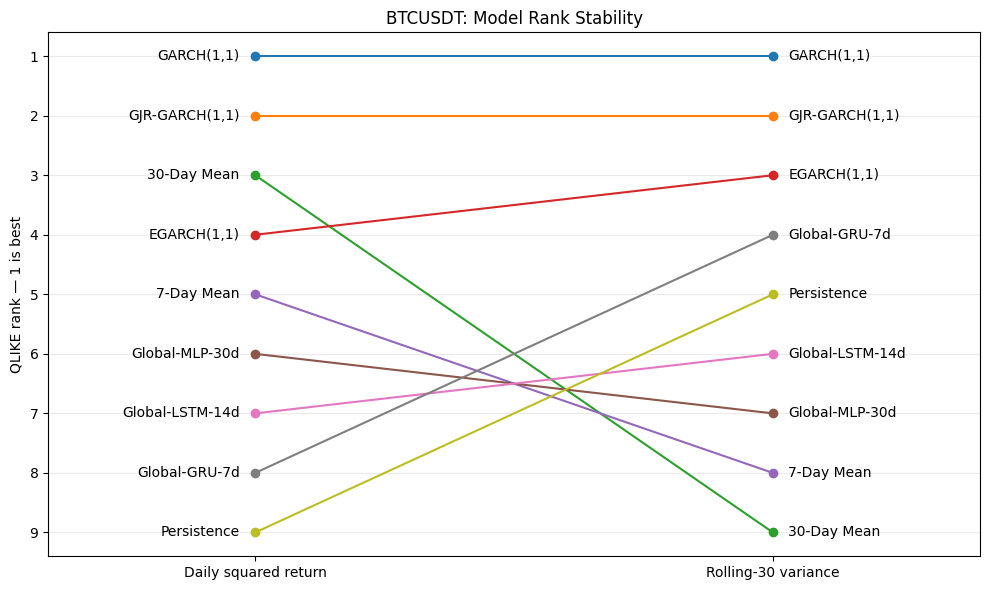

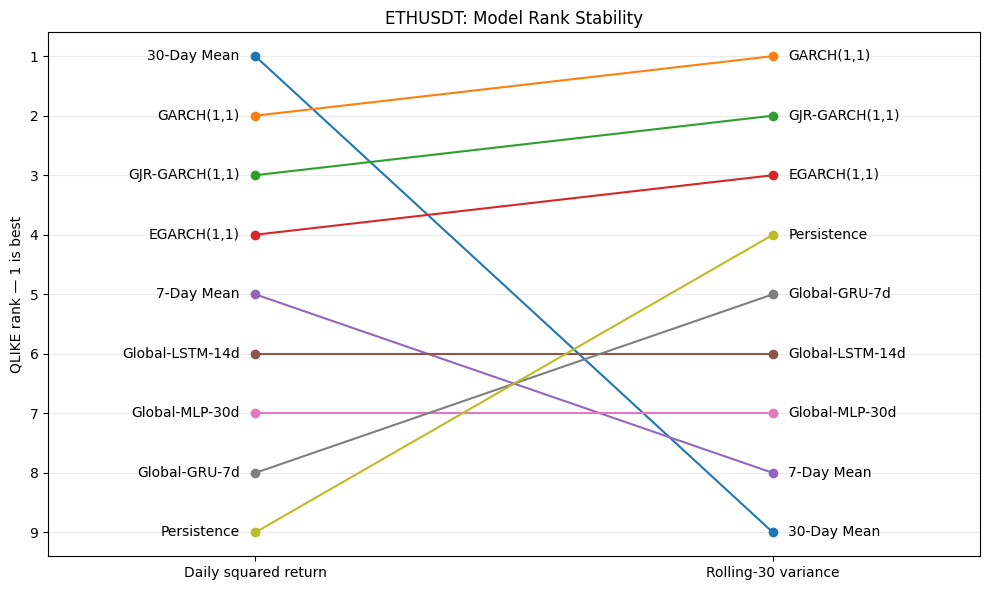

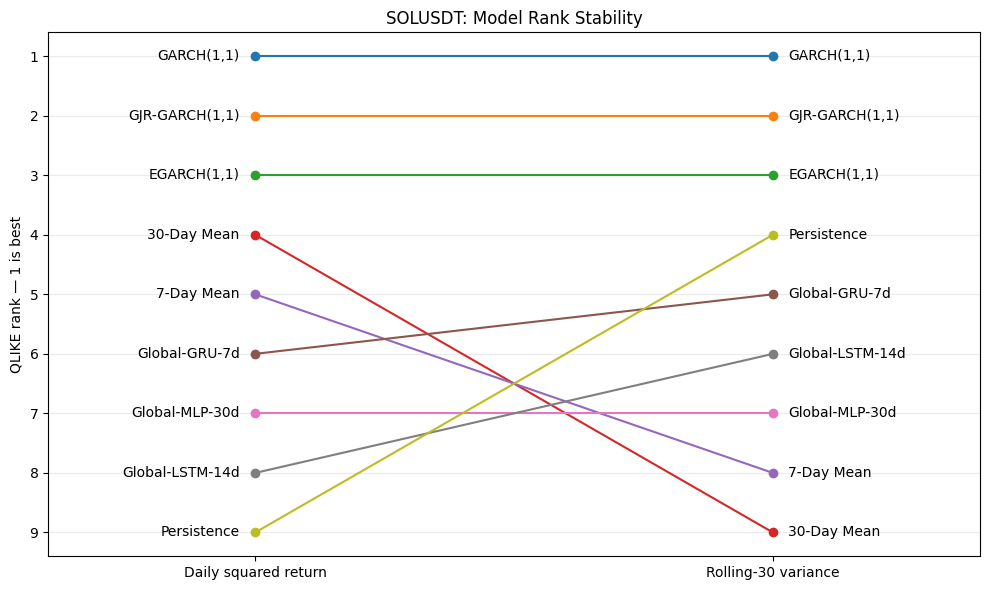

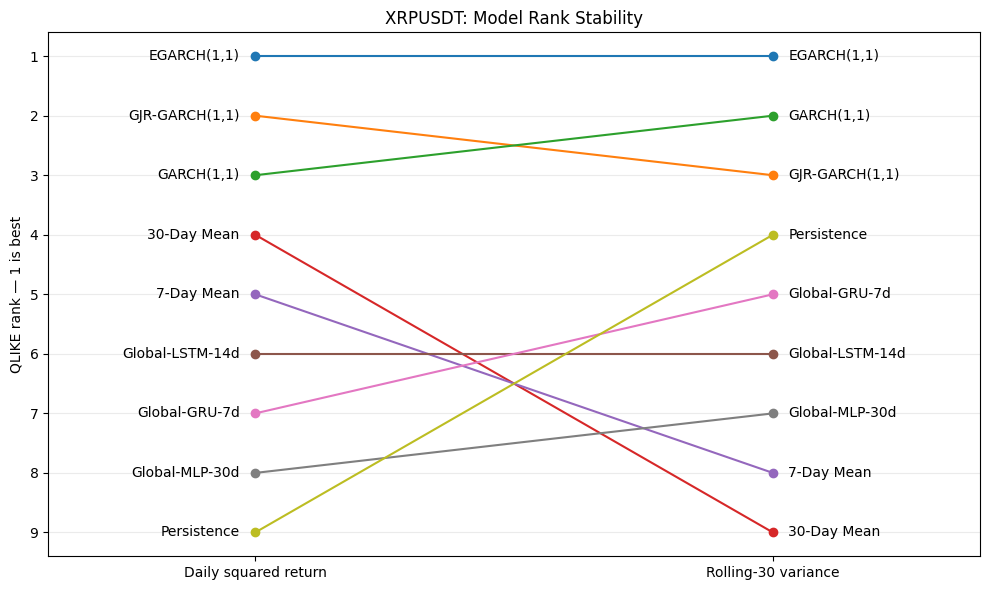

In [12]:
for asset in ASSETS:

    plot_df = (
        cross_target_rank_df.loc[
            cross_target_rank_df[
                "asset"
            ].eq(asset)
        ]
        .sort_values(
            "primary_qlike_rank"
        )
        .copy()
    )

    plt.figure(
        figsize=(10, 6)
    )

    for _, row in (
        plot_df.iterrows()
    ):

        plt.plot(
            [
                0,
                1,
            ],
            [
                row[
                    "primary_qlike_rank"
                ],
                row[
                    "rolling30_qlike_rank"
                ],
            ],
            marker="o",
        )

        plt.text(
            -0.03,
            row[
                "primary_qlike_rank"
            ],
            row[
                "model_key"
            ],
            horizontalalignment="right",
            verticalalignment="center",
        )

        plt.text(
            1.03,
            row[
                "rolling30_qlike_rank"
            ],
            row[
                "model_key"
            ],
            horizontalalignment="left",
            verticalalignment="center",
        )

    plt.xticks(
        [
            0,
            1,
        ],
        [
            "Daily squared return",
            "Rolling-30 variance",
        ],
    )

    plt.ylabel(
        "QLIKE rank — 1 is best"
    )

    plt.title(
        f"{asset}: Model Rank Stability"
    )

    plt.xlim(
        -0.4,
        1.4,
    )

    plt.gca().invert_yaxis()

    plt.grid(
        axis="y",
        alpha=0.25,
    )

    plt.tight_layout()
    plt.show()

## 13. Publication-oriented summary table

This table summarizes the result that matters most for the paper:  
whether ARCH, Global DL or a simple baseline wins under each volatility definition.

In [13]:
publication_rows = []

for asset in ASSETS:

    for target_name in [
        PRIMARY_TARGET,
        ROLLING30_TARGET,
    ]:

        row = (
            family_summary_df.loc[
                family_summary_df[
                    "asset"
                ].eq(asset)
                & family_summary_df[
                    "target_definition"
                ].eq(
                    target_name
                )
            ]
            .iloc[0]
        )

        candidates = [
            (
                "ARCH",
                row[
                    "best_arch_model"
                ],
                row[
                    "best_arch_qlike"
                ],
            ),

            (
                "Global DL",
                row[
                    "best_global_dl_model"
                ],
                row[
                    "best_global_dl_qlike"
                ],
            ),

            (
                "Baseline",
                row[
                    "best_baseline_model"
                ],
                row[
                    "best_baseline_qlike"
                ],
            ),
        ]

        winning_family, winning_model, winning_qlike = min(
            candidates,
            key=lambda item: item[2],
        )

        publication_rows.append({
            "asset":
                asset,

            "target_definition":
                target_name,

            "winning_family":
                winning_family,

            "winning_model":
                winning_model,

            "winning_qlike":
                winning_qlike,

            "best_arch_model":
                row[
                    "best_arch_model"
                ],

            "best_arch_qlike":
                row[
                    "best_arch_qlike"
                ],

            "best_global_dl_model":
                row[
                    "best_global_dl_model"
                ],

            "best_global_dl_qlike":
                row[
                    "best_global_dl_qlike"
                ],

            "best_baseline_model":
                row[
                    "best_baseline_model"
                ],

            "best_baseline_qlike":
                row[
                    "best_baseline_qlike"
                ],
        })


publication_summary_df = (
    pd.DataFrame(
        publication_rows
    )
)

PUBLICATION_SUMMARY_PATH = (
    OUTPUT_DIR
    / "publication_summary_by_asset_and_target.csv"
)

publication_summary_df.to_csv(
    PUBLICATION_SUMMARY_PATH,
    index=False,
)

display(
    publication_summary_df.style.format({
        "winning_qlike":
            "{:.6f}",

        "best_arch_qlike":
            "{:.6f}",

        "best_global_dl_qlike":
            "{:.6f}",

        "best_baseline_qlike":
            "{:.6f}",
    })
)

,asset,target_definition,winning_family,winning_model,winning_qlike,best_arch_model,best_arch_qlike,best_global_dl_model,best_global_dl_qlike,best_baseline_model,best_baseline_qlike
0,BTCUSDT,Daily Squared Return Variance,ARCH,"GARCH(1,1)",1.865873,"GARCH(1,1)",1.865873,Global-MLP-30d,3.751286,30-Day Mean,1.878815
1,BTCUSDT,Rolling-30 Historical Variance,ARCH,"GARCH(1,1)",0.002567,"GARCH(1,1)",0.002567,Global-GRU-7d,0.004830,Persistence,0.004915
2,ETHUSDT,Daily Squared Return Variance,Baseline,30-Day Mean,1.855280,"GARCH(1,1)",1.855979,Global-LSTM-14d,5.195097,30-Day Mean,1.855280
3,ETHUSDT,Rolling-30 Historical Variance,ARCH,"GARCH(1,1)",0.003161,"GARCH(1,1)",0.003161,Global-GRU-7d,0.005485,Persistence,0.005222
4,SOLUSDT,Daily Squared Return Variance,ARCH,"GARCH(1,1)",1.650260,"GARCH(1,1)",1.650260,Global-GRU-7d,2.820048,30-Day Mean,1.661597
5,SOLUSDT,Rolling-30 Historical Variance,ARCH,"GARCH(1,1)",0.002666,"GARCH(1,1)",0.002666,Global-GRU-7d,0.005077,Persistence,0.004887
6,XRPUSDT,Daily Squared Return Variance,ARCH,"EGARCH(1,1)",1.914143,"EGARCH(1,1)",1.914143,Global-LSTM-14d,4.802991,30-Day Mean,2.145177
7,XRPUSDT,Rolling-30 Historical Variance,ARCH,"EGARCH(1,1)",0.004998,"EGARCH(1,1)",0.004998,Global-GRU-7d,0.010544,Persistence,0.009537


## 14. Automated interpretation summary

In [14]:
print(
    "=" * 78
)

print(
    "ROBUSTNESS SUMMARY"
)

print(
    "=" * 78
)

for asset in ASSETS:

    print(
        f"\n{asset}"
    )

    for target_name in [
        PRIMARY_TARGET,
        ROLLING30_TARGET,
    ]:

        row = (
            publication_summary_df.loc[
                publication_summary_df[
                    "asset"
                ].eq(asset)
                & publication_summary_df[
                    "target_definition"
                ].eq(
                    target_name
                )
            ]
            .iloc[0]
        )

        print(
            f"  {target_name}: "
            f"{row['winning_model']} "
            f"[{row['winning_family']}]"
        )

    stability_row = (
        winner_stability_df.loc[
            winner_stability_df[
                "asset"
            ].eq(asset)
        ]
        .iloc[0]
    )

    print(
        "  Winning family stable: "
        f"{stability_row['same_winning_family']}"
    )


stable_family_count = int(
    winner_stability_df[
        "same_winning_family"
    ]
    .sum()
)

print(
    "\n"
    + "-" * 78
)

print(
    "Winning model family is unchanged "
    f"for {stable_family_count}/"
    f"{len(ASSETS)} assets."
)

arch_wins = int(
    publication_summary_df[
        "winning_family"
    ]
    .eq("ARCH")
    .sum()
)

print(
    "ARCH wins "
    f"{arch_wins}/"
    f"{len(publication_summary_df)} "
    "asset-target combinations."
)

print(
    "\nInterpret raw MAE/RMSE/QLIKE "
    "only within a target definition. "
    "Use ranks and winning-family stability "
    "for the cross-target robustness conclusion."
)

ROBUSTNESS SUMMARY

BTCUSDT
  Daily Squared Return Variance: GARCH(1,1) [ARCH]
  Rolling-30 Historical Variance: GARCH(1,1) [ARCH]
  Winning family stable: True

ETHUSDT
  Daily Squared Return Variance: 30-Day Mean [Baseline]
  Rolling-30 Historical Variance: GARCH(1,1) [ARCH]
  Winning family stable: False

SOLUSDT
  Daily Squared Return Variance: GARCH(1,1) [ARCH]
  Rolling-30 Historical Variance: GARCH(1,1) [ARCH]
  Winning family stable: True

XRPUSDT
  Daily Squared Return Variance: EGARCH(1,1) [ARCH]
  Rolling-30 Historical Variance: EGARCH(1,1) [ARCH]
  Winning family stable: True

------------------------------------------------------------------------------
Winning model family is unchanged for 3/4 assets.
ARCH wins 7/8 asset-target combinations.

Interpret raw MAE/RMSE/QLIKE only within a target definition. Use ranks and winning-family stability for the cross-target robustness conclusion.


## 15. Final QC and saved outputs

In [15]:
# Four assets must be represented under each target.
assert (
    all_core_df
    .groupby(
        "target_definition"
    )["asset"]
    .nunique()
    .eq(
        len(ASSETS)
    )
    .all()
)

# QLIKE must remain non-negative.
assert (
    all_core_df[
        "qlike"
    ]
    >= -1e-12
).all()

# Every publication-summary asset must have both target definitions.
assert (
    publication_summary_df
    .groupby("asset")[
        "target_definition"
    ]
    .nunique()
    .eq(2)
    .all()
)

# Every family-summary combination should be unique.
assert not family_summary_df.duplicated(
    subset=[
        "target_definition",
        "asset",
    ]
).any()

print(
    "All final robustness "
    "comparison QC checks passed."
)

print(
    "\nSaved outputs:"
)

for path in [
    ALL_CORE_PATH,
    CROSS_TARGET_RANK_PATH,
    WINNER_STABILITY_PATH,
    FAMILY_SUMMARY_PATH,
    AVERAGE_RANK_PATH,
    BTC_SELECTED_PATH,
    PUBLICATION_SUMMARY_PATH,
]:
    print(
        " -",
        path,
    )

All final robustness comparison QC checks passed.

Saved outputs:
 - /content/drive/MyDrive/Quant Research/results/FINAL_ROBUSTNESS_COMPARISON/all_core_validation_metrics_both_targets.csv
 - /content/drive/MyDrive/Quant Research/results/FINAL_ROBUSTNESS_COMPARISON/cross_target_qlike_rank_comparison.csv
 - /content/drive/MyDrive/Quant Research/results/FINAL_ROBUSTNESS_COMPARISON/winner_stability_by_asset.csv
 - /content/drive/MyDrive/Quant Research/results/FINAL_ROBUSTNESS_COMPARISON/family_comparison_by_target_and_asset.csv
 - /content/drive/MyDrive/Quant Research/results/FINAL_ROBUSTNESS_COMPARISON/average_qlike_rank_by_target.csv
 - /content/drive/MyDrive/Quant Research/results/FINAL_ROBUSTNESS_COMPARISON/btc_selected_standalone_dl_cross_target.csv
 - /content/drive/MyDrive/Quant Research/results/FINAL_ROBUSTNESS_COMPARISON/publication_summary_by_asset_and_target.csv


## Interpretation guide

The most useful outputs for the paper are:

1. **`publication_summary_by_asset_and_target.csv`**  
   Best ARCH, Global DL and baseline model for each asset under both volatility definitions.

2. **`winner_stability_by_asset.csv`**  
   Shows whether the winning model and model family remain unchanged when the target changes.

3. **`family_comparison_by_target_and_asset.csv`**  
   Quantifies the within-target QLIKE advantage of ARCH over Global DL and of Global DL over the strongest baseline.

4. **`cross_target_qlike_rank_comparison.csv`**  
   Shows rank changes for the same models across the two volatility definitions.

5. **`btc_selected_standalone_dl_cross_target.csv`**  
   Robustness comparison of the frozen BTC-only MLP-30d, GRU-7d and LSTM-14d specifications.

### Recommended conclusion logic

A strong robustness conclusion exists if the same broad family — especially ARCH — remains dominant under both:

- the noisy one-day squared-return variance proxy; and
- the much smoother rolling-30 historical-variance target.

Do **not** claim that the rolling-30 experiment is intrinsically "more accurate" because its QLIKE/MAE/RMSE values are numerically smaller. The two targets have different predictability and smoothness.